#  Looking at data shape and structure

Dataset shape: (8761177, 5)
Columns: ['Accel_X', 'Accel_Y', 'Accel_Z', 'Temperature_C', 'Audio_Amp']


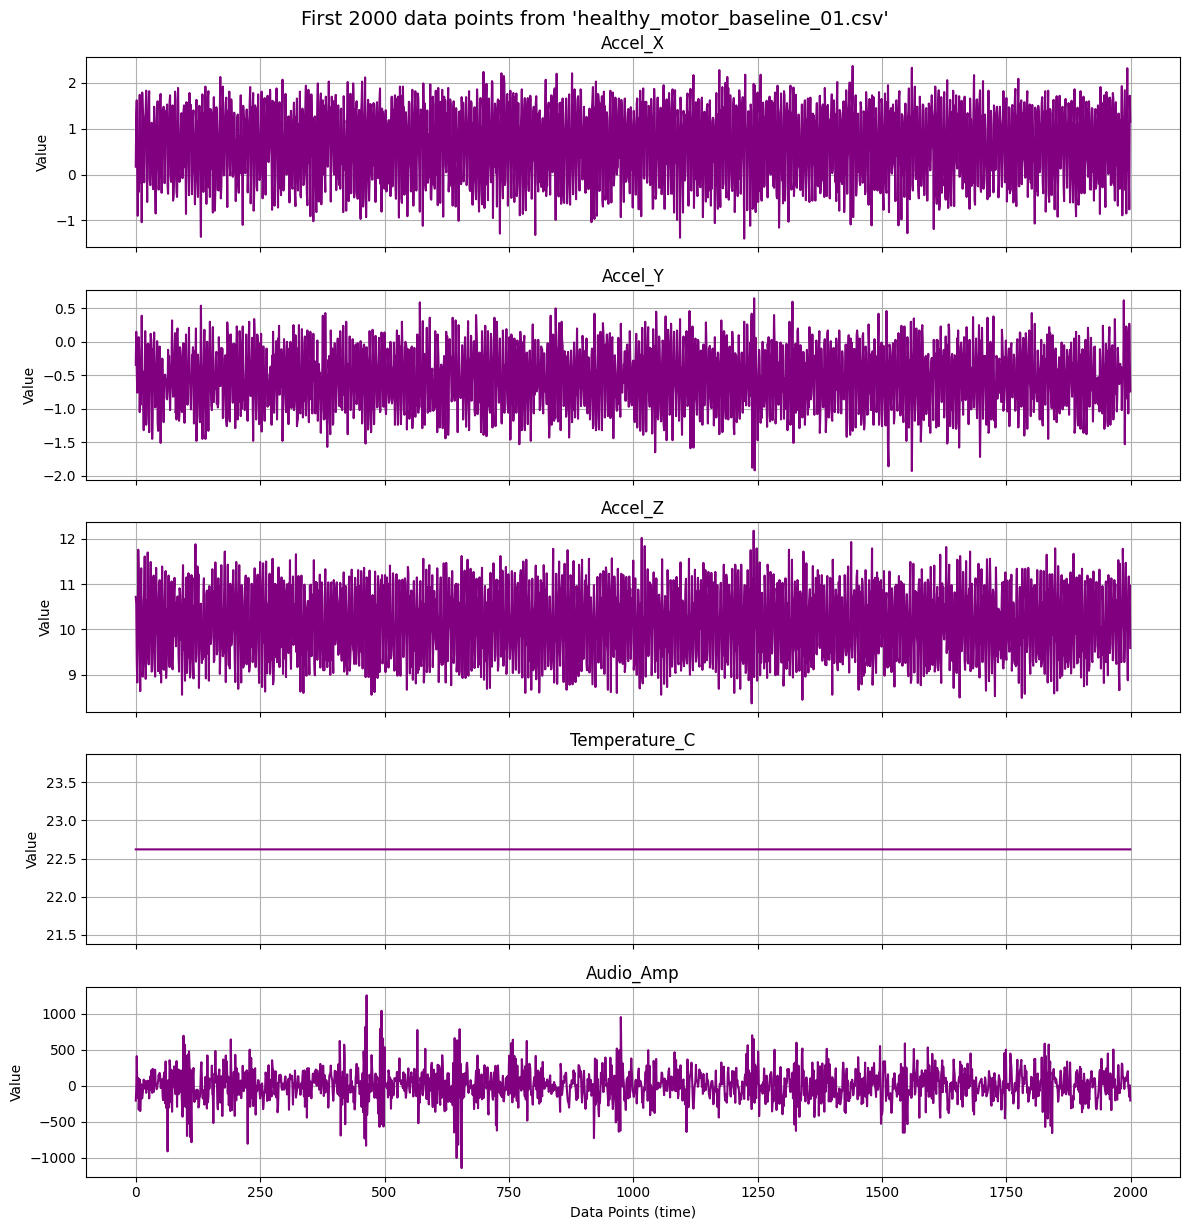

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../datasets/raw/healthy_motor_baseline_01.csv"
dataset = pd.read_csv(file_path)

print(f"Dataset shape: {dataset.shape}")
print(f"Columns: {dataset.columns.tolist()}")

plot_points = 2000
dataset_subset = dataset.head(plot_points)

# Create a subplot for each column in the dataset
num_cols = dataset.shape[1]
fig, axes = plt.subplots(num_cols, 1, figsize=(12, 2.5 * num_cols), sharex=True)

# Handle the case where there is only one column to make axes iterable
if num_cols == 1:
    axes = [axes]

for i, col in enumerate(dataset.columns):
    axes[i].plot(dataset_subset.index, dataset_subset[col], color='purple')
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")
    axes[i].grid(True)

axes[-1].set_xlabel("Data Points (time)")
fig.suptitle(f"First {plot_points} data points from '{file_path.split('/')[-1]}'", fontsize=14)
plt.tight_layout()
plt.show()

---
# Comparing fault data vs normal

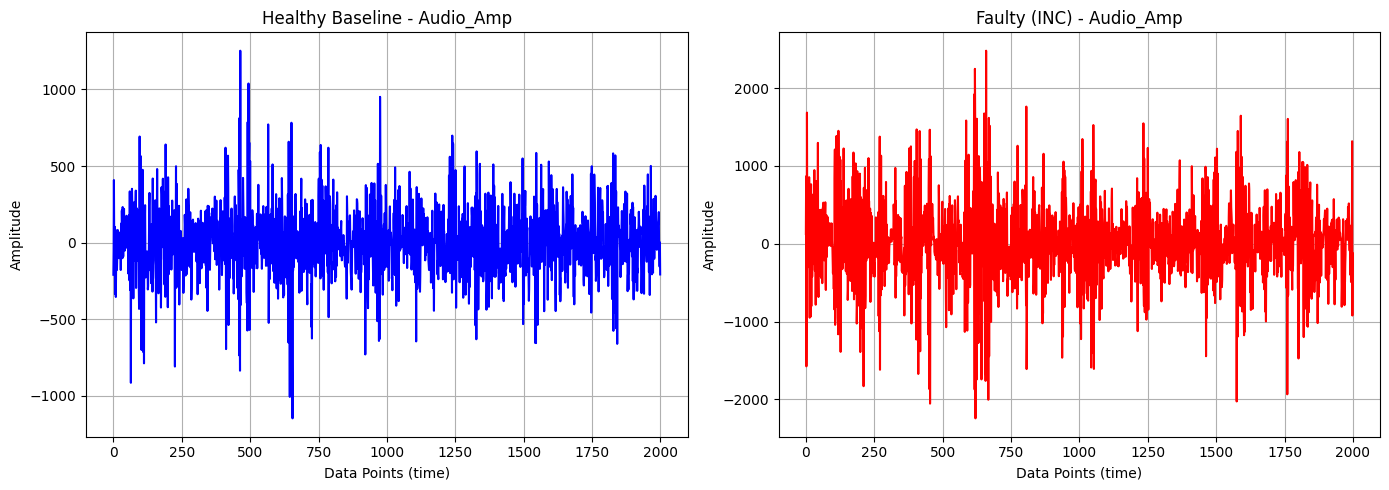

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the new CSV datasets (baseline and an example fault/incipient condition)
healthy_df = pd.read_csv("../datasets/raw/motor_healthy_baseline_01.csv")
faulty_df = pd.read_csv("../datasets/raw/motor_loose_baseline_01.csv")

target_col = 'Audio_Amp'
sampleA = healthy_df[target_col].values[:2000]
sampleB = faulty_df[target_col].values[:2000]

# plot
plt.figure(figsize=(14, 5))

# classA (Healthy)
plt.subplot(1, 2, 1)
plt.plot(sampleA, color='blue')
plt.title(f"Healthy Baseline - {target_col}")
plt.xlabel("Data Points (time)")
plt.ylabel("Amplitude")
plt.grid(True)

# classB (Faulty)
plt.subplot(1, 2, 2)
plt.plot(sampleB, color='red')
plt.title(f"Faulty (INC) - {target_col}")
plt.xlabel("Data Points (time)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

---
# Frequency Domain
using Fast Fourier Transform

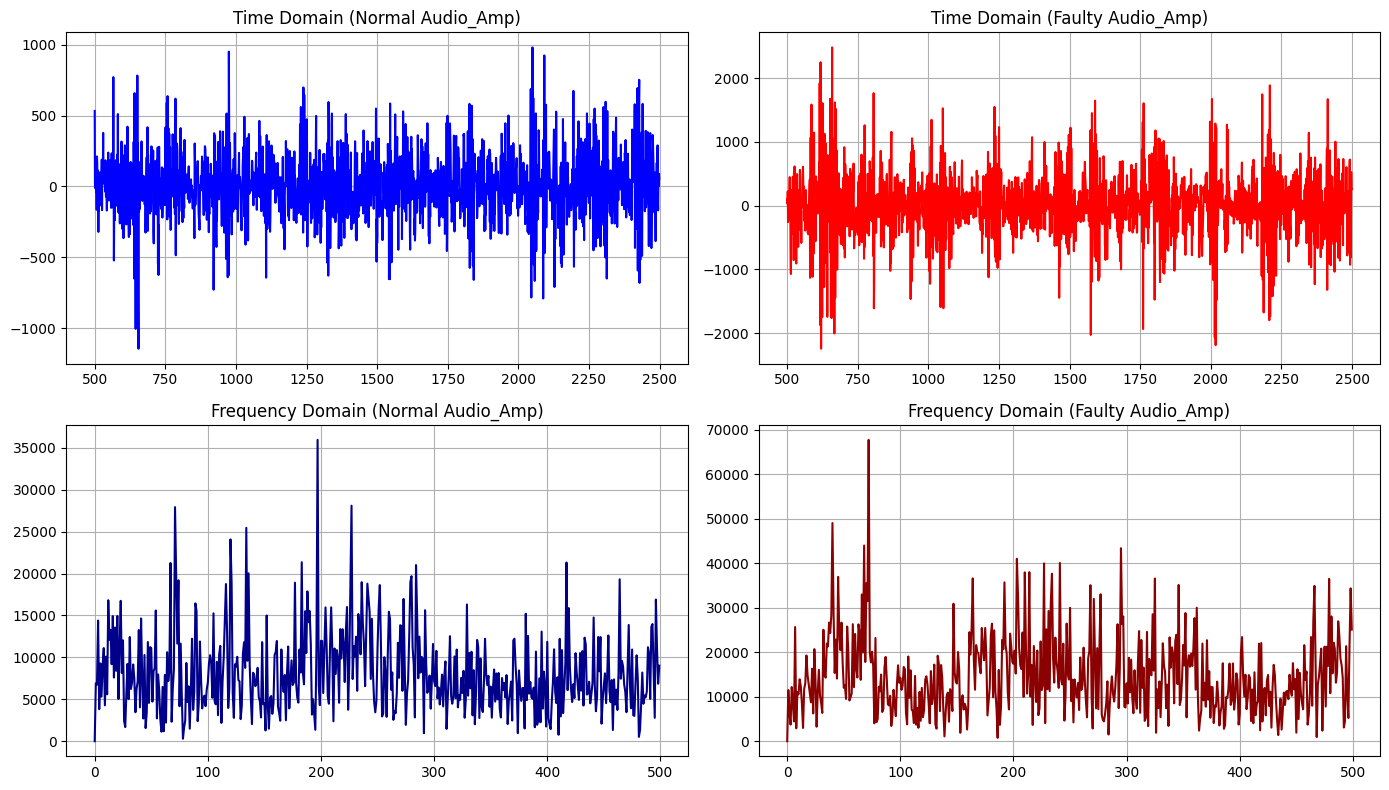

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

healthy_df = pd.read_csv("../datasets/raw/motor_healthy_baseline_01.csv")
faulty_df = pd.read_csv("../datasets/raw/motor_loose_baseline_01.csv")

target_col = 'Audio_Amp'
start_idx = 500  # Skip the initial startup transient
end_idx = 2500

normal_sample = healthy_df[target_col].values[start_idx:end_idx]
faulty_sample = faulty_df[target_col].values[start_idx:end_idx]

# Remove the DC offset (mean value) to eliminate the massive spike at 0 Hz in the FFT
normal_sample_centered = normal_sample - np.mean(normal_sample)
faulty_sample_centered = faulty_sample - np.mean(faulty_sample)

# calc fast fourier transform
# take abs of the fft to get magnitude of the frequencies
fft_normal = np.abs(np.fft.fft(normal_sample_centered))[:500]
fft_faulty = np.abs(np.fft.fft(faulty_sample_centered))[:500]

# plot
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# TL normal time domain
axs[0, 0].plot(range(start_idx, end_idx), normal_sample, color='blue')
axs[0, 0].set_title(f"Time Domain (Normal {target_col})")
axs[0, 0].grid(True)

# TR faulty time domain
axs[0, 1].plot(range(start_idx, end_idx), faulty_sample, color='red')
axs[0, 1].set_title(f"Time Domain (Faulty {target_col})")
axs[0, 1].grid(True)

# BL normal freq domain
axs[1, 0].plot(fft_normal, color='darkblue')
axs[1, 0].set_title(f"Frequency Domain (Normal {target_col})")
axs[1, 0].grid(True)

# BR faulty freq domain
axs[1, 1].plot(fft_faulty, color='darkred')
axs[1, 1].set_title(f"Frequency Domain (Faulty {target_col})")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()